# Comparison of samples

Apply to summary files (output from summary_celltypes_IHOPE.py) in CSV format.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from scripts.comparison import (
    load_celltype_summaries,
    pivot_for_heatmap,
    plot_celltype_heatmap,
    print_numeric_summary,
    pivot_for_tissue_heatmap,
    plot_celltype_heatmap,
    plot_celltype_clustermap
)


Define file names and sample names. Use the output from cell 1 to complete cell 2.

In [5]:
# Make a "fill the gap" template
summaries_dir = Path("../results/reports/NEW")
files = sorted(summaries_dir.glob("celltype_summary_*debugged_summary.csv"))

print("name_map = {")
for f in files:
    print(f'    "{f.name}": "",')
print("}")

name_map = {
    "celltype_summary_IHOPE14_MedLN_BottomLeft_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "",
    "celltype_summary_IHOPE14_MedLN_BottomRight_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "",
    "celltype_summary_IHOPE14_MedLN_TopRight_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "",
    "celltype_summary_IHOPE14_mesLN_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "",
    "celltype_summary_IHOPE20_LN_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "",
    "celltype_summary_IHOPE20_Spleen_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "",
    "celltype_summary_IHOPE26_LN_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "",
    "celltype_summary_IHOPE26_Spleen_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "",
    "celltype_summary_IHOPE27_LN_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "",
    "celltype_summary_IHOPE27_Spleen_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "",
 

In [6]:
name_map = {
    "celltype_summary_IHOPE14_MedLN_BottomLeft_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "IHOPE14 MedLN Bottom Left",
    "celltype_summary_IHOPE14_MedLN_BottomRight_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "IHOPE14 MedLN Bottom Right",
    "celltype_summary_IHOPE14_MedLN_TopRight_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "IHOPE14 MedLN Top Right",
    "celltype_summary_IHOPE14_mesLN_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "IHOPE14 MesLN",
    "celltype_summary_IHOPE20_LN_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "IHOPE20 MedLN",
    "celltype_summary_IHOPE20_Spleen_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "IHOPE20 Spleen",
    "celltype_summary_IHOPE26_LN_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "IHOPE26 MedLN",
    "celltype_summary_IHOPE26_Spleen_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "IHOPE26 Spleen",
    "celltype_summary_IHOPE27_LN_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "IHOPE27 MedLN",
    "celltype_summary_IHOPE27_Spleen_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "IHOPE27 Spleen",
    "celltype_summary_IHOPE39_LN_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "IHOPE39 MedLN",
    "celltype_summary_IHOPE39_MesLN_1_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "IHOPE39 MesLN",
    "celltype_summary_IHOPE39_Spleen_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "IHOPE39 Spleen",
}

In [7]:
file_map = {
    sample: summaries_dir / fname
    for fname, sample in name_map.items()
}

In [8]:
# Sanity check
for sample, path in file_map.items():
    print(sample, ": ", path.name)

IHOPE14 MedLN Bottom Left :  celltype_summary_IHOPE14_MedLN_BottomLeft_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv
IHOPE14 MedLN Bottom Right :  celltype_summary_IHOPE14_MedLN_BottomRight_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv
IHOPE14 MedLN Top Right :  celltype_summary_IHOPE14_MedLN_TopRight_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv
IHOPE14 MesLN :  celltype_summary_IHOPE14_mesLN_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv
IHOPE20 MedLN :  celltype_summary_IHOPE20_LN_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv
IHOPE20 Spleen :  celltype_summary_IHOPE20_Spleen_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv
IHOPE26 MedLN :  celltype_summary_IHOPE26_LN_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv
IHOPE26 Spleen :  celltype_summary_IHOPE26_Spleen_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv
IHOPE27 MedLN :  celltype_summary_IHOPE27_LN_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv
IHOPE27 Spleen :  ce

Generate data frame and matrix for heatmaps:

In [9]:
df = load_celltype_summaries(file_map=file_map)

matrix = pivot_for_heatmap(df)

### Donor-grouping:

In [14]:
donor_map = {
    "IHOPE14 MedLN Bottom Left": "IHOPE14",
    "IHOPE14 MedLN Bottom Right": "IHOPE14",
    "IHOPE14 MedLN Top Right": "IHOPE14",
    "IHOPE14 MesLN": "IHOPE14",
    "IHOPE20 MedLN": "IHOPE20",
    "IHOPE20 Spleen": "IHOPE20",
    "IHOPE26 MedLN": "IHOPE26",
    "IHOPE26 Spleen": "IHOPE26",
    "IHOPE27 MedLN": "IHOPE27",
    "IHOPE27 Spleen": "IHOPE27",
    "IHOPE39 MedLN": "IHOPE39",
    "IHOPE39 MesLN": "IHOPE39",
    "IHOPE39 Spleen": "IHOPE39",
}

df["donor"] = df["sample"].map(donor_map)

### Tissue-grouping:

In [12]:
tissue_map = {
    "IHOPE14 MedLN Bottom Left": "MedLN",
    "IHOPE14 MedLN Bottom Right": "MedLN",
    "IHOPE14 MedLN Top Right": "MedLN",
    "IHOPE14 MesLN": "MesLN",
    "IHOPE20 MedLN": "MedLN",
    "IHOPE20 Spleen": "Spleen",
    "IHOPE26 MedLN": "MedLN",
    "IHOPE26 Spleen": "Spleen",
    "IHOPE27 MedLN": "MedLN",
    "IHOPE27 Spleen": "Spleen",
    "IHOPE39 MedLN": "MedLN",
    "IHOPE39 MesLN": "MesLN",
    "IHOPE39 Spleen": "Spleen",
}

df["tissue"] = df["sample"].map(tissue_map)

Using mean  (avoid dominance of large samples):

In [27]:
df_tissue = (
    df.groupby(["tissue", "level", "cell_type"], as_index=False)
      .agg(pct_total=("pct_total", "mean"))
)

Decide how you want to handle unannotated cells:

In [ ]:
DROP_UNCLASSIFIED = False   # recalculates percentages excluding unclassified
HIDE_UNCLASSIFIED = True  # keeps percentages as-is, just drops row from plot

## Tables

Generate table with type annotations (or other if desired)

In [ ]:
# Keep only major lineage annotations
type_df = df[df["level"] == "type"].copy()

# sanity check: should sum to ~100 for every sample
print(
    type_df.groupby("sample")["pct_total"]
    .sum()
    .round(2)
)

# Create main table with ALL type-level annotations
main_table = (
    type_df.pivot(
        index="sample",
        columns="cell_type",
        values="pct_total"
    )
    .fillna(0)
    .round(1)
)

# optional: reorder columns manually for readability
preferred_order = [
    "T",
    "B",
    "Myeloid",
    "NK",
    "Stromal",
    "Endothelial",
    "unclassified"
]

# keep only columns that actually exist
main_table = main_table[
    [col for col in preferred_order if col in main_table.columns]
]

main_table.index.name = "Sample"

print(main_table)

# export
main_table.to_csv("main_celltype_table.csv")

In [ ]:
main_table.to_excel("main_celltype_table.xlsx")

Including total cells for each sample:

In [10]:
# Add total cell counts
total_cells = (
    type_df.groupby("sample")["n_cells"]
    .first()
    .rename("Total cells")
)
main_table_with_counts = main_table.join(total_cells)
print(main_table_with_counts)
main_table_with_counts.to_csv("main_celltype_table_with_counts.csv")
main_table_with_counts.to_excel("main_celltype_table_withcounts.xlsx")

NameError: name 'type_df' is not defined

Intermediate and subtype tables:

In [ ]:
for level in ["intermediate", "subtype"]:
    print(f"\n── {level} ──")
    print(df[df["level"] == level]["cell_type"].unique().tolist())

In [ ]:
import pandas as pd
from pathlib import Path
import subprocess
import json

# ── Table definitions ────────────────────────────────────────────────────────
table_definitions = {
    "Intermediate": ["T_memory", "T_naive", "CD4_T", "CD8_T", "B_memory", "B_naive"],
    "T_subtypes": [
        "Activated_CD4", "Activated_CD8", "TCM_CD4", "TCM_CD8",
        "TEM_CD4", "TEM_CD8", "TEMRA_CD4", "TEMRA_CD8",
        "TN_CD4", "TN_CD8", "Treg", "TfH_like", "T_terminal", "T_unassigned"
    ],
    "B_subtypes": ["B_GC_follicular", "B_plasmablast_extrafollicular", "B_unassigned"],
    "Myeloid_subtypes": ["Monocyte_Macrophage", "cDC1", "cDC2", "FDC"],
    "Nonimmune_subtypes": ["Fibroblast", "Basement_Membrane", "Blood_Endothelial", "Lymphatic_Endothelial"],
}


# ── Build tables ─────────────────────────────────────────────────────────────
tables = {}
for name, cell_types in table_definitions.items():
    sub_df = df[df["cell_type"].isin(cell_types)].copy()
    table = (
        sub_df.pivot(index="sample", columns="cell_type", values="pct_total")
        .fillna(0)
        .round(1)
    )
    # keep only columns that exist, in defined order
    table = table[[c for c in cell_types if c in table.columns]]
    table.index.name = "Sample"
    tables[name] = table

# ── Export to Excel (one sheet per table) ────────────────────────────────────
excel_path = "supplementary_celltype_tables.xlsx"
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for name, table in tables.items():
        table.to_excel(writer, sheet_name=name)
print(f"Saved {excel_path}")

## Plots

**Cell type heatmap:**

Choose if you want to use raw percentages or log-scaled in the first block.

In [28]:
USE_LOG = False  # set True for log scaled percentages

plot_matrix = np.log10(matrix + 0.1) if USE_LOG else matrix
scale_label = "log"    if USE_LOG else "linear"
cbar_label  = "Log percentage (+0.1)" if USE_LOG else "Percentage"

matrix = pivot_for_heatmap(df, exclude_unclassified=DROP_UNCLASSIFIED)

if HIDE_UNCLASSIFIED:
    plot_matrix = plot_matrix.drop(index="unclassified", errors="ignore")

Generate plots:

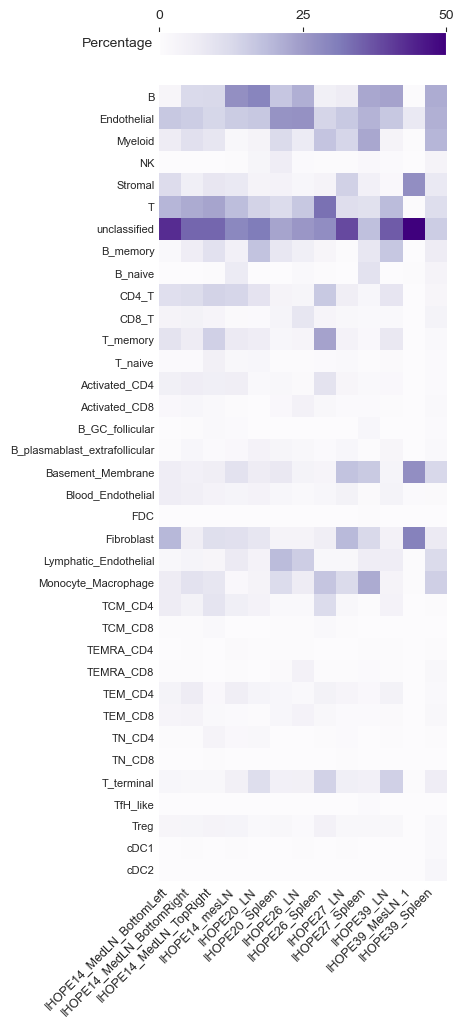

In [29]:
plot_celltype_heatmap(
    plot_matrix,
    scale = scale_label,
    colorbar_legend=cbar_label
)

Clustered:

In [ ]:
# Both axes clustered:

plot_celltype_clustermap(
    plot_matrix,
    colorbar_legend=cbar_label,
    scale=scale_label
)

In [ ]:
# Only cluster samples (X-axis):

plot_celltype_clustermap(
    plot_matrix,
    colorbar_legend=cbar_label,
    scale=scale_label,
    cluster_rows=False,
    cluster_cols=True
)

Correlation metric can also be used, this can be an advantage when sample sizes differ, which they do here

In [ ]:
# With correlation metric instead of Euclidean

plot_celltype_clustermap(
    plot_matrix,
    scale=scale_label,
    colorbar_legend=cbar_label,
    cluster_rows=False,
    cluster_cols=True,
    metric="correlation"
)

**Tissue-grouped**

Select raw percentages or log-scaled in the first block.

In [ ]:
USE_LOG = False  # set True for log scaled percentages

import numpy as np
matrix_tissue = pivot_for_tissue_heatmap(df_tissue)
plot_matrix_tissue = np.log10(matrix_tissue + 0.1) if USE_LOG else matrix_tissue
scale_label  = "log"    if USE_LOG else "linear"
cbar_label   = "Percentage (log +0.1)" if USE_LOG else "Percentage"

Raw percentages:

In [ ]:
plot_celltype_heatmap(
    plot_matrix_tissue,
    colorbar_legend=cbar_label,
    scale=scale_label
)

Stacked barplot for broad/lineage cell types:

In [ ]:
palette = plot_celltype_stacked_barplot(
    df,
    levels=["type"],
    ylim=(0,100)
)

plot_celltype_stacked_barplot(
    df,
    levels=["type"],
    x="tissue",
    palette=palette,
    ylim=(0, 100)
)

Intermediate cell types (note that they do not necessarily add up to 100% and the Y axis limits may need tuning):

In [ ]:
palette = plot_celltype_stacked_barplot(
    df,
    levels=["intermediate"],
    x="sample",
    title="Cell type composition per sample",
    ylim = (0, 100)
)

In [ ]:
plot_celltype_stacked_barplot(
    df_tissue,
    levels=["intermediate"],
    x="tissue",
    palette=palette,  # reuse colors
    ylim = (0, 30)
)